# a05 Example - Bayesian Optimization using Ax over Laser-Fiber Alignment Benchtop: Local Search

# Install External Libraries for Optimizer Implementation

In [1]:
# !python -m pip install ax-platform

# Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from time import sleep

import pyscan as ps
# from pyscan.drivers.thorlabs.thorlabsct1p import ThorlabsCT1P # fiber z-stage
from pyscan.drivers.thorlabs.thorlabspm16_120 import ThorlabsPM16_120 # laser power meter
from laser_fiber_align_plots import input_separate_output_init, input_separate_output_plot

## Setup devices

In [3]:
devices = ps.ItemAttribute()


devices.x1 = ps.Agilent33500('USB0::0x0957::0x5707::MY53804557::INSTR', 1)
devices.y1 = ps.Agilent33500('USB0::0x0957::0x5707::MY53804557::INSTR', 2)

devices.x2 = ps.Agilent33500('USB0::0x0957::0x2307::SG50000115::INSTR', 1)
devices.y2 = ps.Agilent33500('USB0::0x0957::0x2307::SG50000115::INSTR', 2)

devices.pm16_120 = ThorlabsPM16_120()

devices.laser = ps.PulseLaser('COM7')

COM7


## Define a measure function

In [4]:
def measure_power(expt):
    d = ps.ItemAttribute()
    d.power = devices.pm16_120.power
    return d

# Define live plot

In [5]:
@ps.live_plot
def plot_optim_live(expt):
    global fig, axs
    input_separate_output_plot(axs,
                               expt.x1_voltage, expt.y1_voltage,
                               expt.x2_voltage, expt.y2_voltage,
                               expt.power)

# Define runinfo

In [6]:
runinfo = ps.RunInfo()
runinfo.measure_function = measure_power

# Implement `AbstractOptimizeScan` with `AxOptimizeScan`

# Instantiate OptimizeScan

In [7]:
# z0 = 0.
# zf = 100.
# v0 = -3.
# vf = 3.
# vb = (v0, vf)
x1v0 = -0.8
x1vf = -0.6
y1v0 = 1.8
y1vf = 2.0
x2v0 = 0.9
x2vf = 1.1
y2v0 = 1.0
y2vf = 1.2

In [8]:
# z_p = ps.AxOptimizeDeviceProperty('ct10', 'position', 0, (z0, zf),
#                                   optimizer_input='z_p_readout',
#                                   initialization_scans=None)
x1 = ps.AxOptimizeDeviceProperty('x1', 'voltage', -0.7, (x1v0, x1vf),
                                 optimizer_input='x1_voltage',
                                 type='float',
                                 initialization_scans=[-0.7])
y1 = ps.AxOptimizeDeviceProperty('y1', 'voltage', 1.9, (y1v0, y1vf),
                                 optimizer_input='y1_voltage',
                                 type='float',
                                 initialization_scans=[1.89])
x2 = ps.AxOptimizeDeviceProperty('x2', 'voltage', 1.0, (x2v0, x2vf),
                                 optimizer_input='x2_voltage',
                                 type='float',
                                 initialization_scans=[1.04])
y2 = ps.AxOptimizeDeviceProperty('y2', 'voltage', 1.1, (y2v0, y2vf),
                                 optimizer_input='y2_voltage',
                                 type='float',
                                 initialization_scans=[1.12])

In [9]:
runinfo.scan0 = ps.AxOptimizeScan((x1, y1, x2, y2),
                                  'power',
                                  dt=1., n_max=100,
                                  global_improvement_threshold=1e-4,
                                  global_improvement_index_window=20,
                                  global_improvement_start_index=50,
                                  extremum='max')

# Run Experiments

In [10]:
expt = ps.Experiment(runinfo, devices)
expt.start_thread()

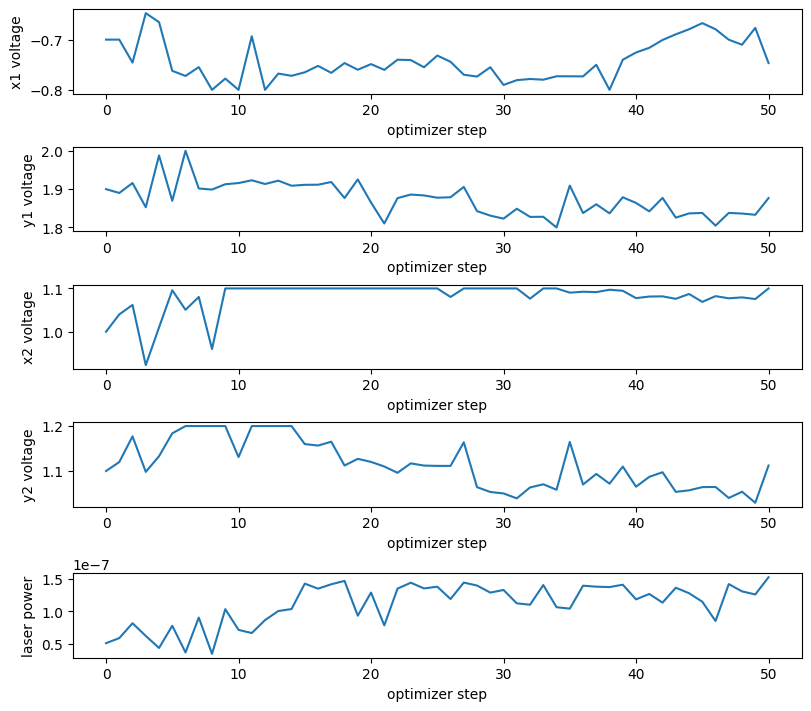

In [11]:
fig, axs = input_separate_output_init()
try:
    plot_optim_live(expt)
except KeyboardInterrupt:
    expt.stop()

In [12]:
expt.__dict__

{'runinfo': <pyscan.measurement.run_info.RunInfo at 0x1485d72e150>,
 'devices': <itemattribute.item_attribute.ItemAttribute at 0x1485d5f7020>,
 'expt_thread': <Thread(Thread-3 (run), stopped daemon 14912)>,
 'iteration': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50.]),
 'x1_voltage': array([-0.7       , -0.7       , -0.74575341, -0.64735688, -0.66524636,
        -0.76214145, -0.77232118, -0.75474414, -0.8       , -0.77758621,
        -0.8       , -0.69329428, -0.8       , -0.76762599, -0.77206148,
        -0.76507396, -0.75229527, -0.7661542 , -0.74668677, -0.75991167,
        -0.74875455, -0.76023727, -0.7399917 , -0.74073161, -0.75506238,
        -0.73168224, -0.7441456 , -0.76986738, -0.77354204, -0.75492305,
        -0.79023643, -0.78070448, -0.77

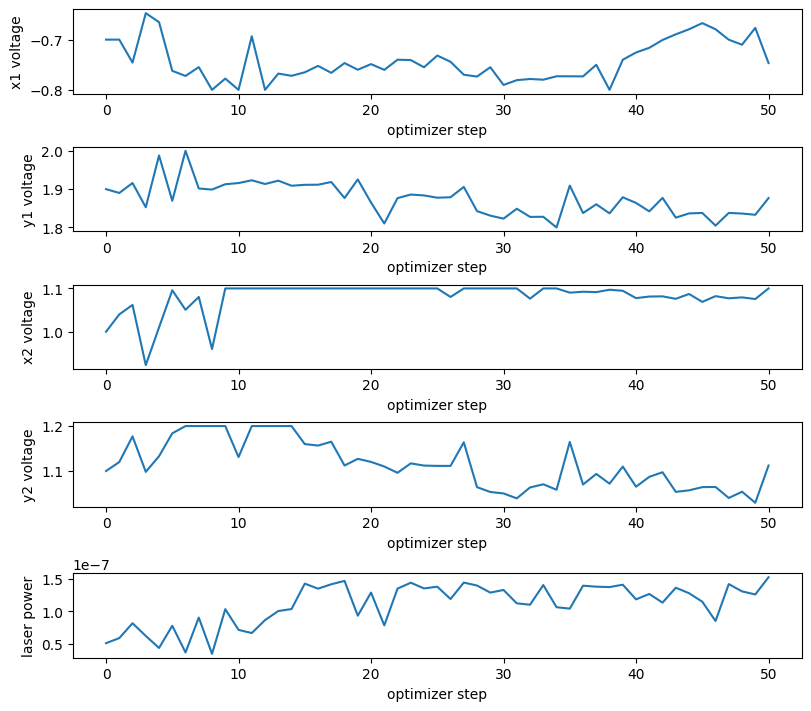

In [13]:
fig, axs = input_separate_output_init()
input_separate_output_plot(axs,
                           expt.x1_voltage, expt.y1_voltage,
                           expt.x2_voltage, expt.y2_voltage,
                           expt.power)